In [2]:
#checking cell: where is everything?
from google.colab import drive
drive.mount('/content/drive')

import os

#list what's inside your AI4_Data folder
base = '/content/drive/MyDrive'
print("Folders inside MyDrive:")
print(os.listdir(base))

print("\nFolders inside AI4_Data:")
print(os.listdir(base + '/AI4_Data'))

print("\nFolders inside AI4_Data/Processed:")
proc_path = base + '/AI4_Data/Processed'
if os.path.exists(proc_path):
    print(os.listdir(proc_path))
else:
    print("Processed folder does NOT exist")

Mounted at /content/drive
Folders inside MyDrive:
['Colab Notebooks', 'TPS Pseudocode CW.gdoc', 'AI4_Data', 'JSONL_FilePractice.ipynb', 'LSDDA']

Folders inside AI4_Data:
['Raw', 'Processed', 'ByteEntropy_Temp', 'Notebooks']

Folders inside AI4_Data/Processed:
['tf0_processed.parquet', 'tf1_ByteEntropy.parquet', 'tf1_processed.parquet']


In [3]:
#load tf1
import pandas as pd

TF1_PATH = '/content/drive/MyDrive/AI4_Data/Processed/tf1_processed.parquet'
tf1 = pd.read_parquet(TF1_PATH)

print("Loaded successfully!")
print("Shape:", tf1.shape)
tf1.head(3)

Loaded successfully!
Shape: (158158, 570)


,label,gen.size,gen.vsize,gen.has_debug,gen.exports,gen.imports,gen.has_relocations,gen.has_resources,gen.has_signature,gen.has_tls,...,byte.255,str.numstrings,str.avlength,str.printabledist,str.printables,str.entropy,str.paths,str.urls,str.registry,str.MZ
0,1,349811.0,28672.0,0.0,0.0,55.0,0.0,1.0,0.0,0.0,...,13644.0,3863.0,17.643541,NaN,68157.0,5.683164,6.0,22.0,0.0,7.0
1,-1,33776.0,36864.0,0.0,0.0,33.0,0.0,1.0,0.0,0.0,...,330.0,82.0,11.097561,NaN,910.0,5.454550,0.0,0.0,0.0,2.0
2,0,161280.0,184320.0,0.0,0.0,155.0,1.0,1.0,0.0,0.0,...,0.0,1452.0,15.486915,NaN,22487.0,5.668189,0.0,204.0,0.0,2.0


In [4]:
#count real labels
tf1['label'].value_counts()

,count
label,
1,63713
0,52338
-1,42107


In [5]:
#check percentage distribution
tf1['label'].value_counts(normalize=True)

,proportion
label,
1,0.402844
0,0.330922
-1,0.266234


In [6]:
#drop unlabeled rows
tf1_clean = tf1[tf1['label'].isin([0, 1])].copy()

tf1_clean['label'].value_counts(), tf1_clean.shape

(label
 1    63713
 0    52338
 Name: count, dtype: int64,
 (116051, 570))

In [7]:
#train/validation split
from sklearn.model_selection import train_test_split

#features and labels
x = tf1_clean.drop(columns=['label'])
y = tf1_clean['label']

#split data
X_train, X_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,    #20% of data will go to validation
    stratify=y,       #label proportions are kept equal
    random_state=42   #reproducibilty
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

print("\nLabel Distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nLabel Distribution in validation set:")
print(y_val.value_counts(normalize=True))

Train shape: (92840, 569)
Validation shape: (23211, 569)

Label Distribution in training set:
label
1    0.549009
0    0.450991
Name: proportion, dtype: float64

Label Distribution in validation set:
label
1    0.549007
0    0.450993
Name: proportion, dtype: float64


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [9]:
#build LR pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()), #scaling
    ('lr', LogisticRegression(
        random_state= 42,
        max_iter=300,             #increase iterations for convergence
        solver='liblinear'        #good for classification
    ))
])

In [10]:
#train the model
from sklearn.impute import SimpleImputer

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fix NaNs
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=300,
        solver='liblinear',
        random_state=42
    ))
])

In [11]:
lr_pipeline.fit(X_train, y_train)
print("Training complete!")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['hdr.coff.machine' 'hdr.coff.characteristics' 'hdr.optional.subsystem'
 'hdr.optional.dll_characteristics' 'hdr.optional.magic' 'sect.sections'
 'str.printabledist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Training complete!


In [12]:
#predicted labels (0 or 1)
lr_preds = lr_pipeline.predict(X_val)

#predicted probabilities (ROC-AUC)
lr_probs = lr_pipeline.predict_proba(X_val)[:, 1]

print("Predictions:", lr_preds)
print("Probabilities:", lr_probs)
print("complete.")

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['hdr.coff.machine' 'hdr.coff.characteristics' 'hdr.optional.subsystem'
 'hdr.optional.dll_characteristics' 'hdr.optional.magic' 'sect.sections'
 'str.printabledist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['hdr.coff.machine' 'hdr.coff.characteristics' 'hdr.optional.subsystem'
 'hdr.optional.dll_characteristics' 'hdr.optional.magic' 'sect.sections'
 'str.printabledist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Predictions: [1 1 0 ... 1 0 0]
Probabilities: [0.78965682 0.71748521 0.28164322 ... 0.67009407 0.24864295 0.33351056]
complete.


In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

accuracy = accuracy_score(y_val, lr_preds)
precision = precision_score(y_val, lr_preds)
recall = recall_score(y_val, lr_preds)
f1 = f1_score(y_val, lr_preds)
roc_auc = roc_auc_score(y_val, lr_probs)

cm = confusion_matrix(y_val, lr_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.7305587867821292
Precision: 0.751219512195122
Recall: 0.7613591775876952
F1 Score: 0.7562553589523735
ROC-AUC: 0.8073000158538193

Confusion Matrix:
 [[7255 3213]
 [3041 9702]]


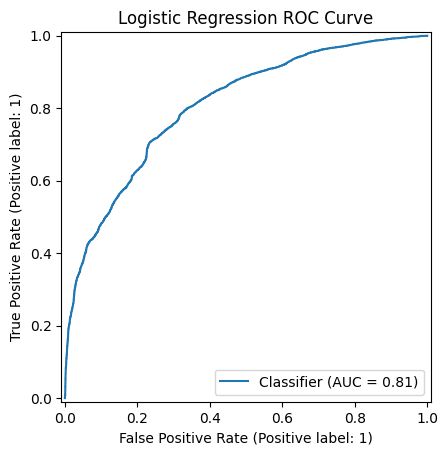

In [14]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_val, lr_probs)
plt.title("Logistic Regression ROC Curve")
plt.show()

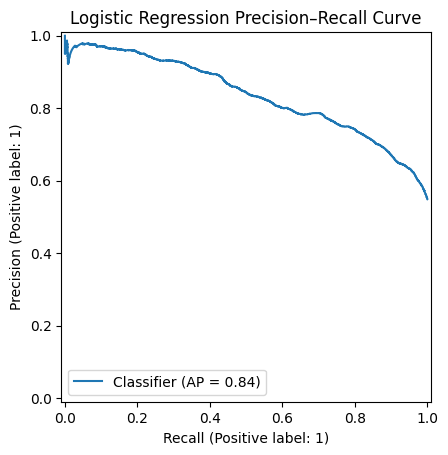

In [15]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_val, lr_probs)
plt.title("Logistic Regression Precision–Recall Curve")
plt.show()

In [17]:
import joblib
joblib.dump(lr_pipeline, '/content/drive/MyDrive/AI4_Data/Outputs/lr_baseline_model.joblib')

['/content/drive/MyDrive/AI4_Data/Outputs/lr_baseline_model.joblib']